# **Exploratory Data Analysis**

## **Index**<br>

[1. **Import Libraries and Data**](#1st-bullet)<br>

[2. **Dataset**](#2nd-bullet)<br>
- [2.1 Initial Data Exploration](#3rd-bullet)<br>
    - [2.1.2 Checking Missing Values](#4th-bullet)<br>
    - [2.1.3 Checking and Treating Duplicates](#5th-bullet)<br>
    - [2.1.4 Converting Data Types](#6th-bullet)<br>
    - [2.1.5 Data Visualization](#7th-bullet)<br>

<a id="1st-bullet"></a>
## 1. Import Libraries and Data


In [239]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import numpy as np
import math
from itertools import product
import plotly.express as px

# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set()

In [240]:
#import and read csv
df_flights = pd.read_csv('DM_AIAI_FlightsDB.csv')
df_customers = pd.read_csv('DM_AIAI_CustomerDB.csv')

In [241]:
flights = df_flights.copy()
customers = df_customers.copy()

<a id="2nd-bullet"></a>
## 2. Dataset


<a id="3rd-bullet"></a>
### 2.1 Initial Data Exploration

In [242]:
flights.shape

(608436, 10)

In [243]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

In [244]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [245]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [246]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

In [247]:
flights.describe()

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000
mean,550037.873084,2020.000000,6.500000,3.908107,0.983944,7939.341419,793.777781,235.251678,2.324835
std,258935.180575,0.816497,3.452055,5.057889,2.003785,10260.421873,1025.918521,983.233374,9.725168
min,100018.000000,2019.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326961.000000,2019.000000,3.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,550834.000000,2020.000000,6.500000,0.000000,0.000000,856.400000,85.275000,0.000000,0.000000
75%,772194.000000,2021.000000,9.250000,7.200000,0.900000,15338.175000,1533.712500,0.000000,0.000000
max,999986.000000,2021.000000,12.000000,21.000000,11.000000,42040.000000,4204.000000,7496.000000,74.000000


In [248]:
flights_metric = ['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']
flights_nonmetric = ['YearMonthDate']

<a id="4th-bullet"></a>
#### 2.1.2 Checking Missing Values


In [249]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

<a id="5th-bullet"></a>
#### 2.1.3 Checking and Treating Duplicates


In [250]:
#check number of duplicates
flights.duplicated().sum()

2903

In [251]:
#dropping duplicates
flights.drop_duplicates(inplace = True)

In [252]:
flights.duplicated(subset = ['Loyalty#', 'Year', 'Month']).sum()

3001

In [253]:
flights.drop_duplicates(subset = ['Loyalty#', 'Year', 'Month'], keep='first', inplace = True)

<a id="6th-bullet"></a>
#### 2.1.4 Converting Data Types


In [254]:
#convert YearMonthDate to Datetime data type
flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'])

In [255]:
flights.dtypes

Loyalty#                             int64
Year                                 int64
Month                                int64
YearMonthDate               datetime64[ns]
NumFlights                         float64
NumFlightsWithCompanions           float64
DistanceKM                         float64
PointsAccumulated                  float64
PointsRedeemed                     float64
DollarCostPointsRedeemed           float64
dtype: object

<a id="7th-bullet"></a>
#### 2.1.5 Data Visualization


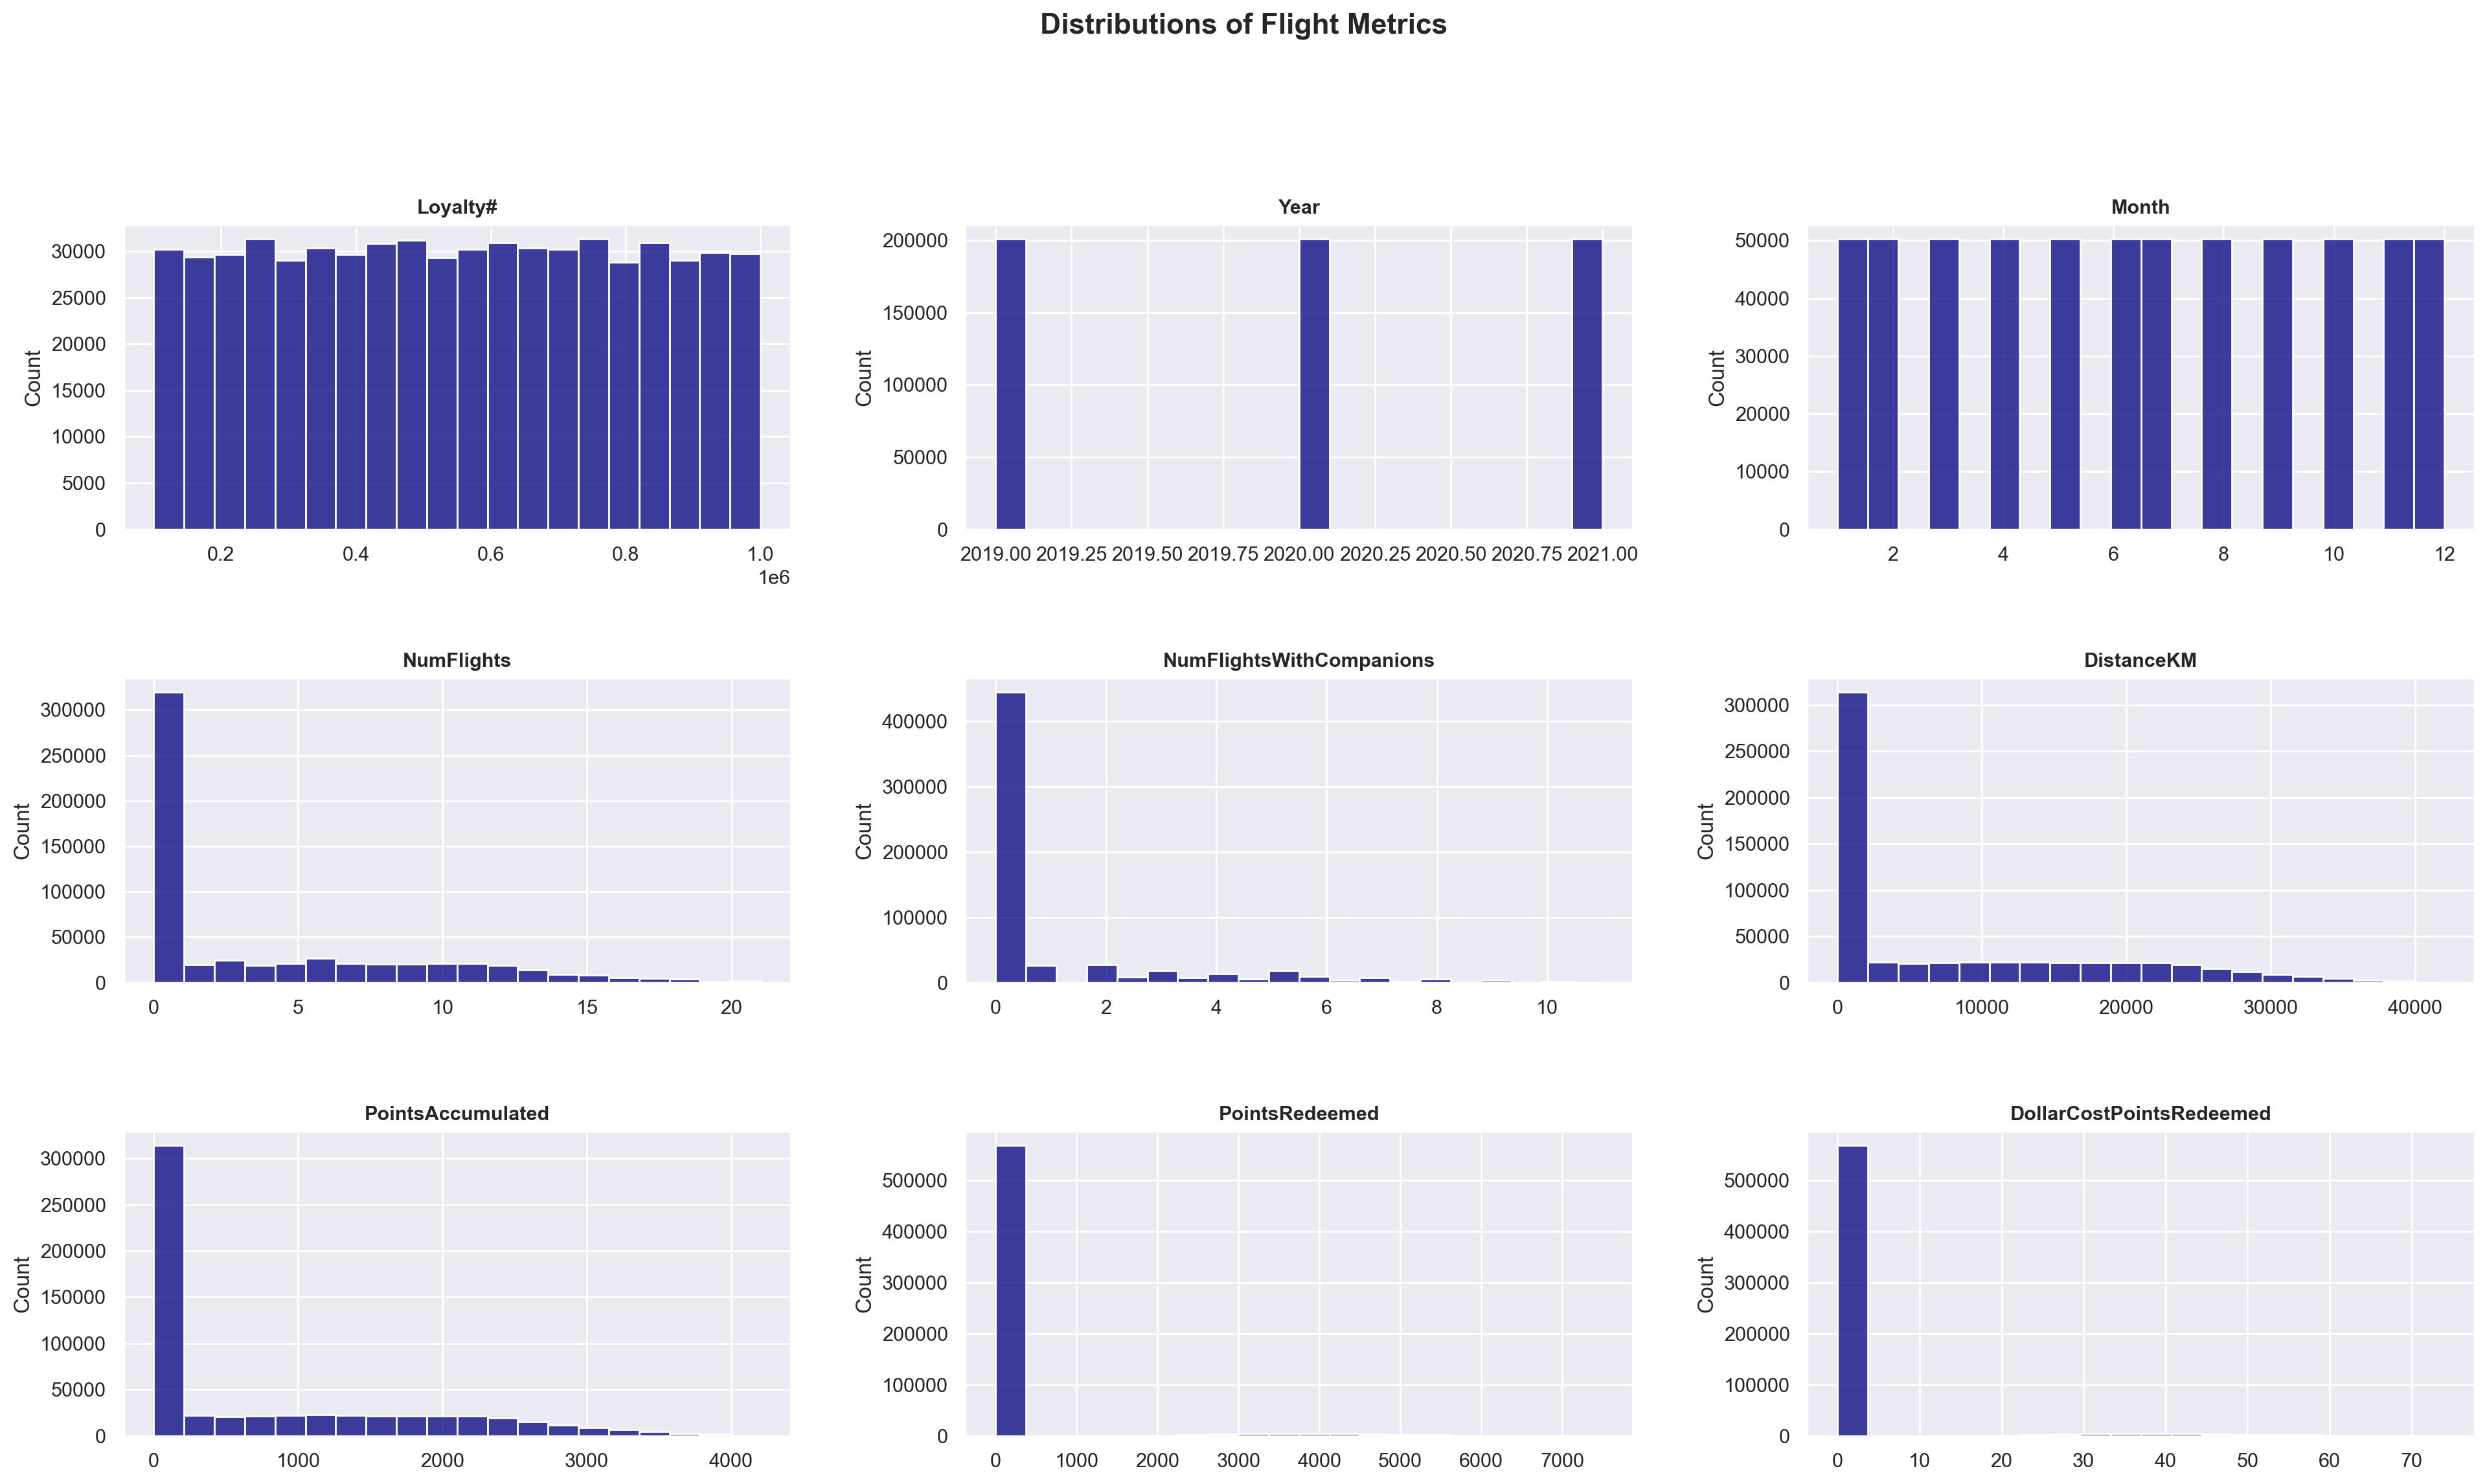

In [256]:
plots_per_row = 3
n_rows = math.ceil(len(flights_metric) / plots_per_row)

plt.figure(figsize=(20, 12))

for i, col in enumerate(flights_metric):
    plt.subplot(n_rows, plots_per_row, i + 1)
    sns.histplot(flights[col].dropna(), bins=20, color='navy')   
    plt.title(col, fontsize=11, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("Count")
    
plt.suptitle("Distributions of Flight Metrics", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96], pad=3)
plt.show()

In [257]:
#check how much of PointsRedeemed and DollarCostPointsRedeemed is = 0:
perc_pr = (flights['PointsRedeemed'] == 0).sum()/len(flights) * 100
perc_dcpr = (flights['DollarCostPointsRedeemed'] == 0).sum()/len(flights) * 100
print(f"Percentage of 0 in Points Redeemed: {perc_pr} \nPercentage of 0 in Dollar Cost Points Redeemed: {perc_dcpr}")

Percentage of 0 in Points Redeemed: 94.17010216884746 
Percentage of 0 in Dollar Cost Points Redeemed: 94.17010216884746


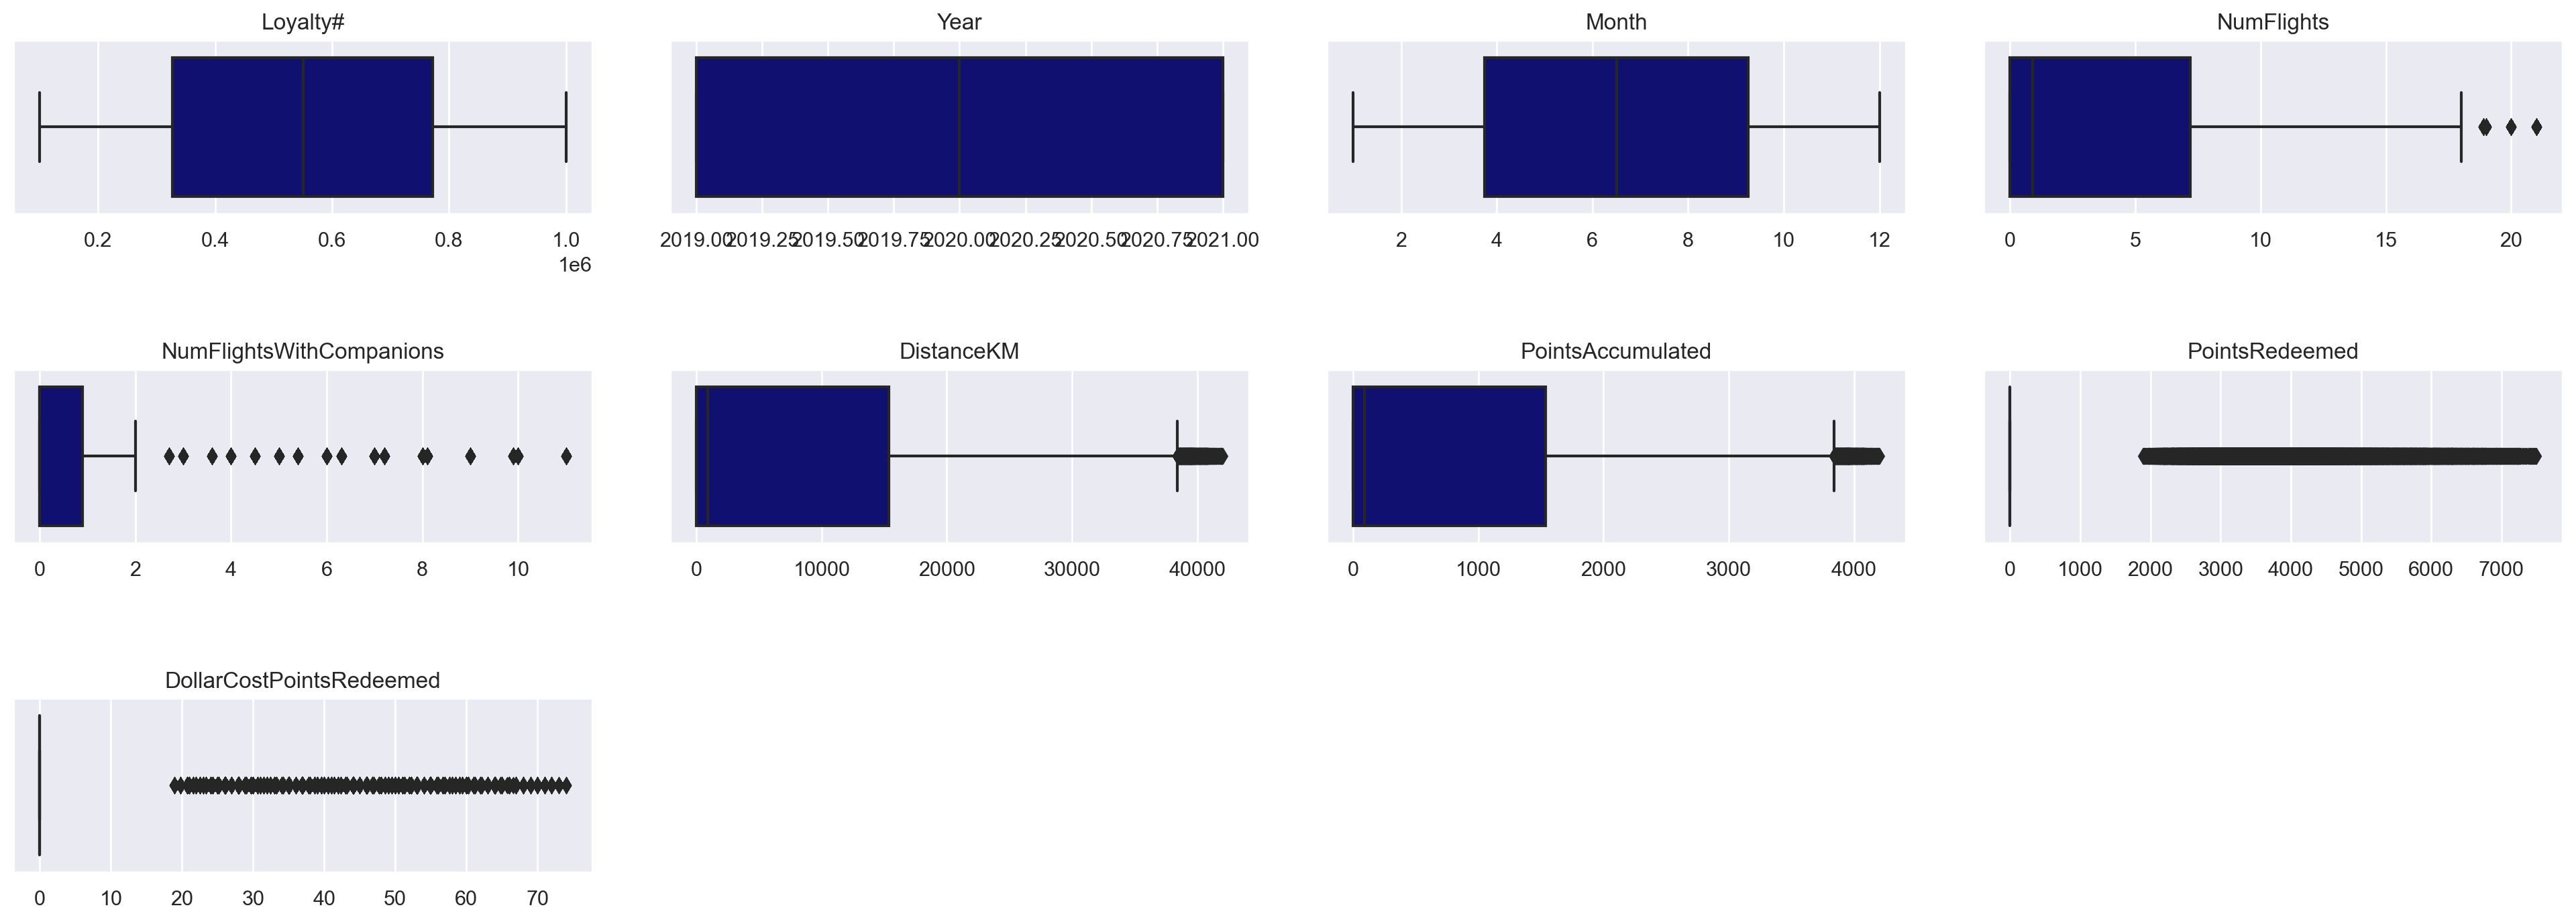

In [258]:
plots_per_row = 4
plt.figure(figsize=(20, 8))  
for i, col in enumerate(flights_metric):
    plt.subplot(math.ceil(len(flights_metric) / plots_per_row), plots_per_row, i + 1)
    sns.boxplot(x=flights[col], color='navy')
    plt.title(f"{col}")
    plt.xlabel("")
plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.96])
plt.show()

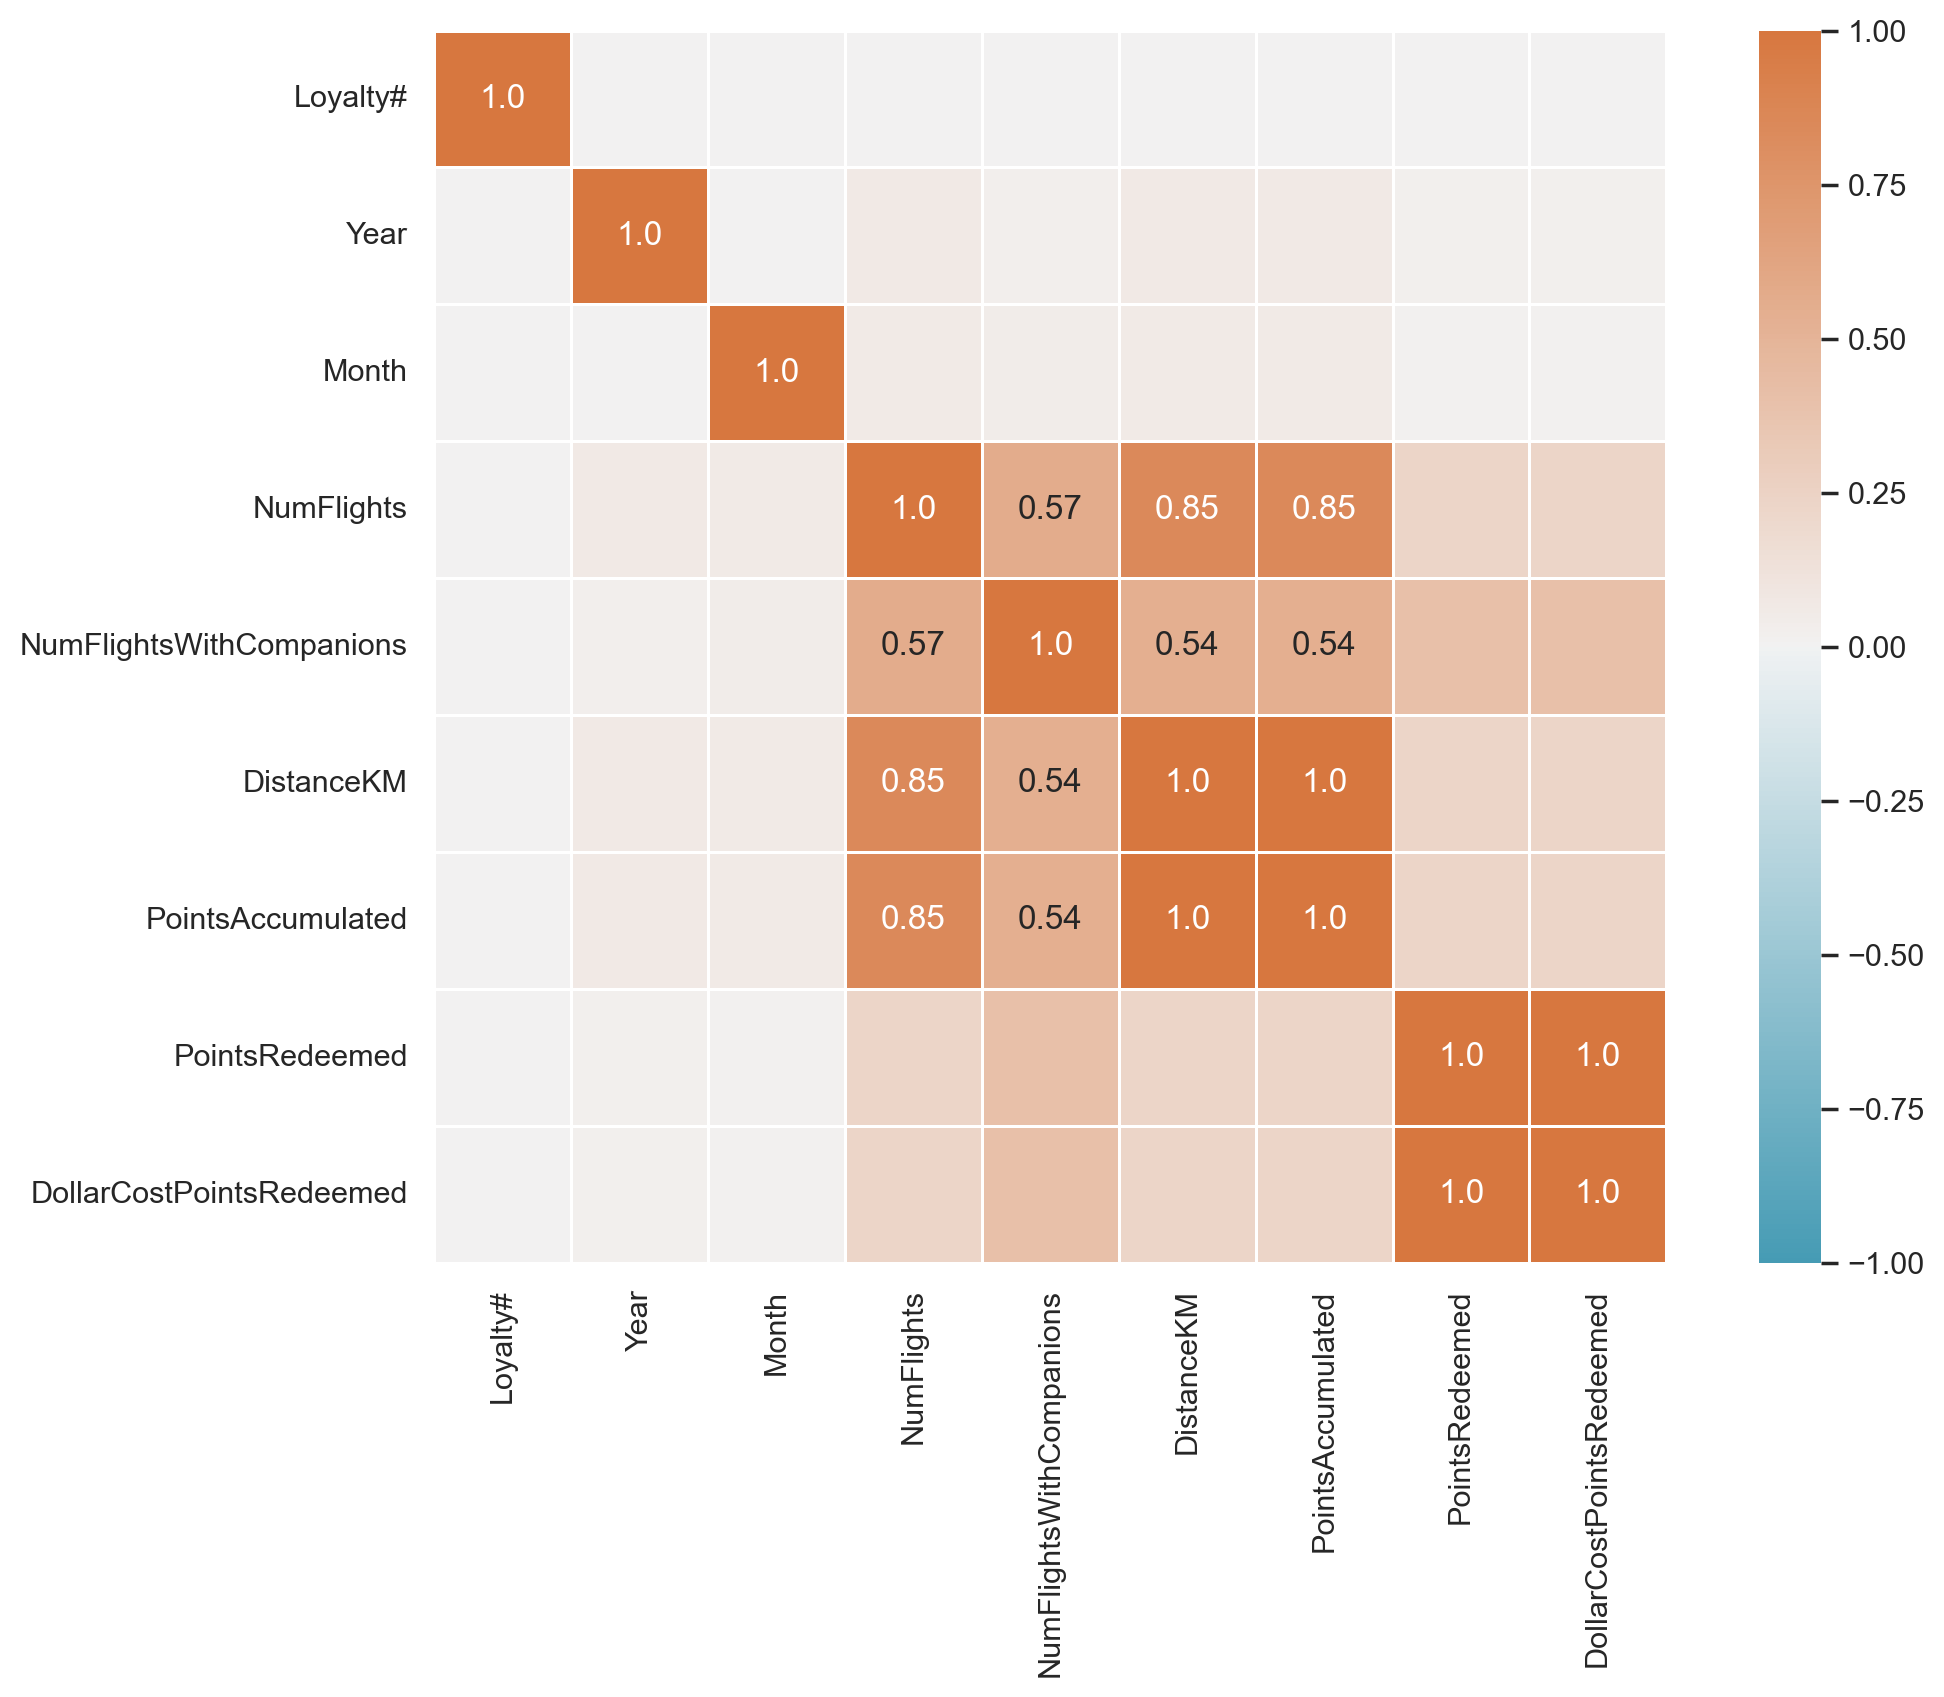

In [259]:
corr = flights[flights_metric].corr(method="spearman")
corr = corr.round(2)
fig = plt.figure(figsize=(12, 8))
mask_annot = np.absolute(corr.values) >= 0.5 
annot = np.where(mask_annot, corr.values, np.full(corr.shape,"")) 
sns.heatmap(data=corr, 
            annot=annot, 
            fmt='s', 
            vmin=-1, vmax=1, 
            center=0, 
            square=True, 
            linewidths=.5, 
            cmap=sns.diverging_palette(220, 30, s=80, l=60, as_cmap=True)
            )
plt.show()

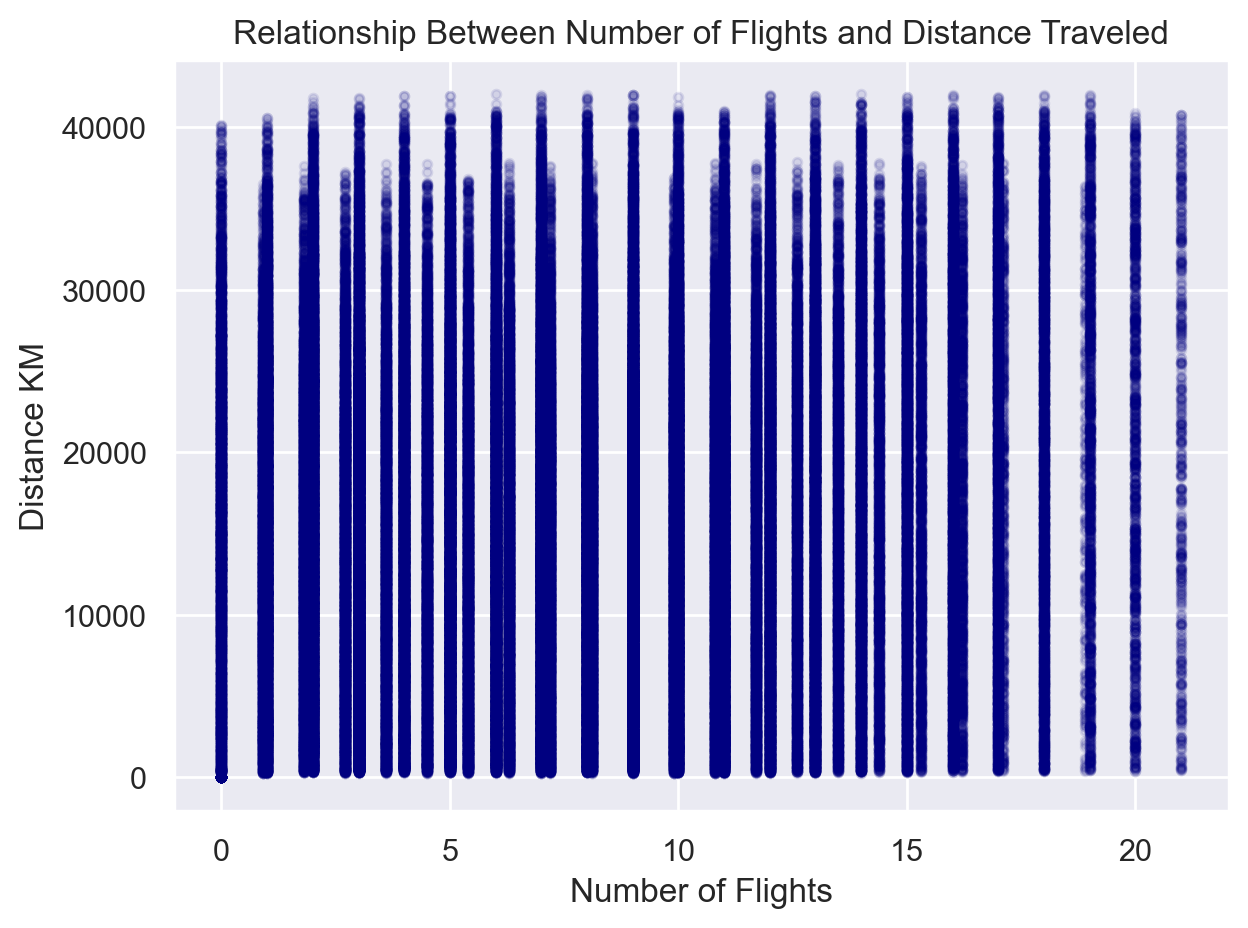

In [260]:
plt.scatter(flights['NumFlights'], flights['DistanceKM'], color='navy', alpha=0.1, s=10 )
plt.xlabel('Number of Flights')
plt.ylabel('Distance KM')
plt.title('Relationship Between Number of Flights and Distance Traveled')
plt.tight_layout()
plt.show()

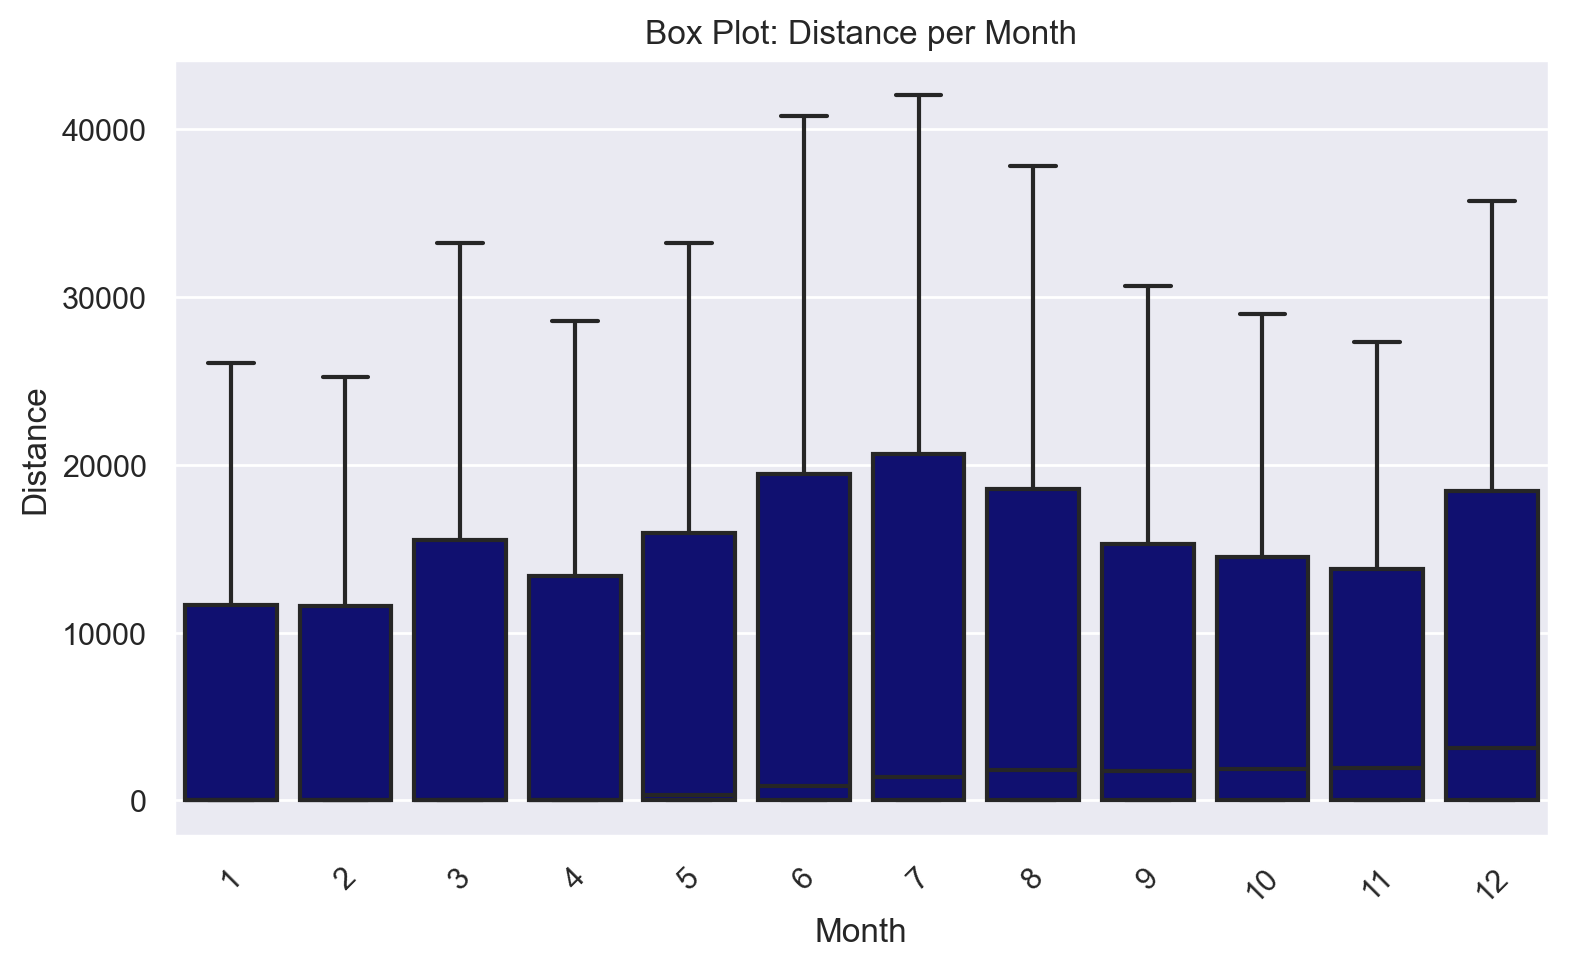

In [261]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Month', y='DistanceKM', data=flights, color='navy')
plt.title('Box Plot: Distance per Month')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [262]:
promo_ids = customers.loc[customers['EnrollmentType'] == '2021 Promotion', 'Loyalty#']
standard_ids = customers.loc[customers['EnrollmentType'] == 'Standard', 'Loyalty#']

In [263]:
promo_flights = flights[flights['Loyalty#'].isin(promo_ids)]
standard_flights = flights[flights['Loyalty#'].isin(standard_ids)]

In [264]:
promo_avg = promo_flights.groupby('Loyalty#')['NumFlights'].sum().mean()
standard_avg = standard_flights.groupby('Loyalty#')['NumFlights'].sum().mean()

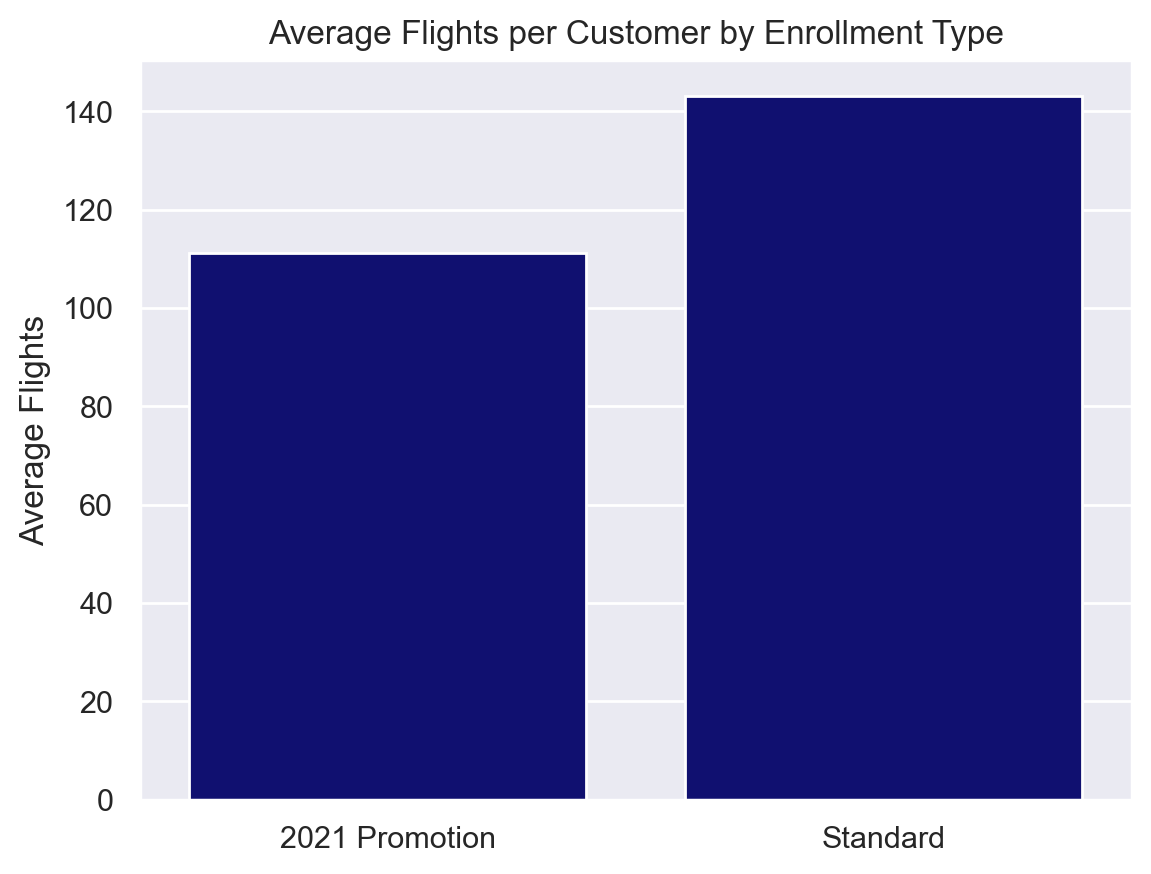

In [265]:
flight_comparison = pd.DataFrame({
    'EnrollmentType': ['2021 Promotion', 'Standard'],
    'AvgFlightsPerCustomer': [promo_avg, standard_avg]
})

sns.barplot(data=flight_comparison, x='EnrollmentType', y='AvgFlightsPerCustomer', color='navy')
plt.title('Average Flights per Customer by Enrollment Type')
plt.ylabel('Average Flights')
plt.xlabel('')
plt.show()


In [266]:
flights_over_time = (
    flights.groupby('YearMonthDate', as_index=False)['NumFlights'].sum()
    .rename(columns={'NumFlights': 'TotalFlights'})
)

distance_over_time = (
    flights.groupby('YearMonthDate', as_index=False)['DistanceKM'].sum()
    .rename(columns = {'DistanceKM' : 'TotalDistanceKM'}))

flights_distance = pd.merge(flights_over_time, distance_over_time, on='YearMonthDate', how='inner')
flights_distance['TotalDistanceKM_scaled'] = flights_distance['TotalDistanceKM'] / 1000  # converts KM to 'thousands of KM'



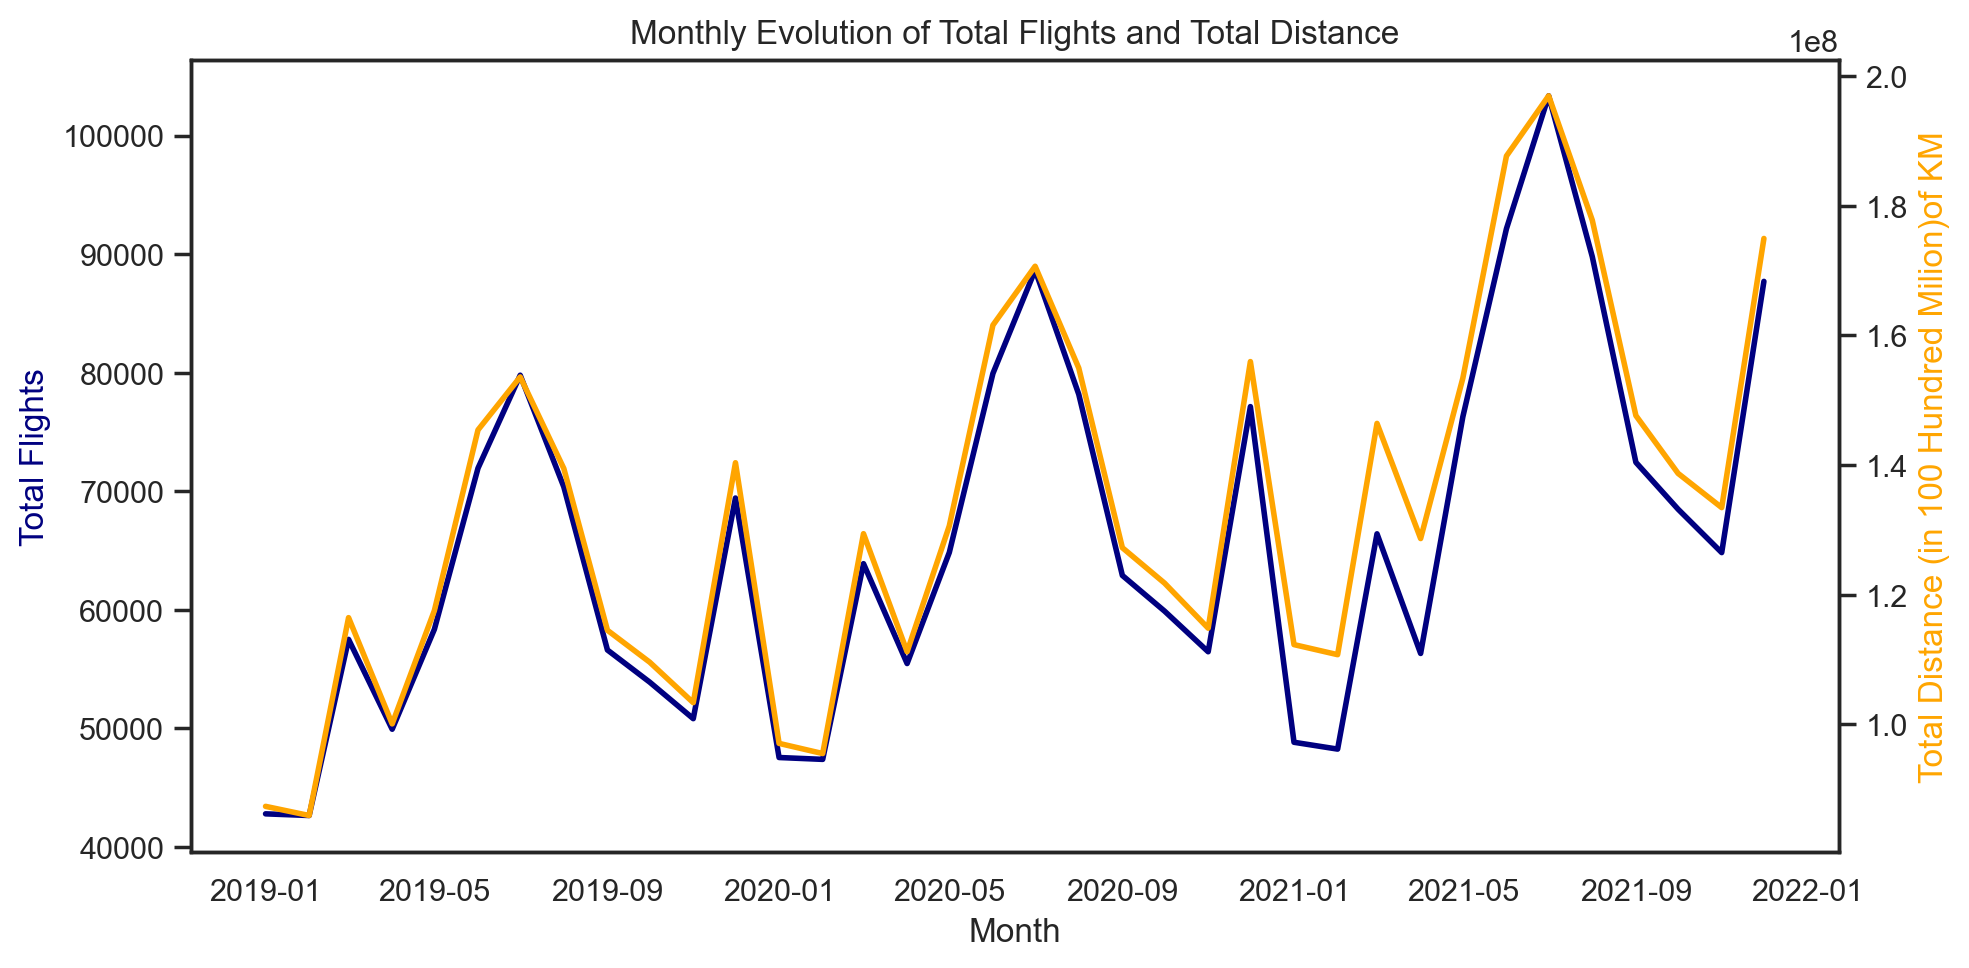

In [267]:
sns.set_style("white")
fig, ax1 = plt.subplots(figsize=(10,5))

# Left axis — total flights
sns.lineplot(
    data=flights_distance, x='YearMonthDate', y='TotalFlights',
    ax=ax1, color='navy', linewidth=2
)
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Flights', color='navy')
ax1.tick_params(axis='y')
ax1.grid(False)

# Right axis — total distance
ax2 = ax1.twinx()
sns.lineplot(
    data=flights_distance, x='YearMonthDate', y='TotalDistanceKM',
    ax=ax2, color='orange', linewidth=2
)
ax2.set_ylabel('Total Distance (in 100 Hundred Milion)of KM', color='orange')
ax2.tick_params(axis='y')
ax2.grid(False)

plt.title('Monthly Evolution of Total Flights and Total Distance')
fig.tight_layout()
plt.show()
